# Fase 1 - *Ex Ante*

## 1 - Coleta e tratamento dos dados

In [371]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

In [372]:
markers = pd.read_csv("./data/marcacoes.csv")
proxies = pd.read_csv("./data/proxies.csv")

markers['data'] = pd.to_datetime(markers['data'])
proxies['data'] = pd.to_datetime(proxies['data'])

markers = markers.set_index("data").sort_index()
proxies = proxies.set_index("data").sort_index()

### Analisando as séries

Podemos observar em ambos os casos que temos séries não estacionárias (i.e. média e variância não são constantes). Para operar melhor com essas séries, o ideal é criarmos uma versão normalizada dos dados.


### Obtendo o retorno médio normalizado

A partir da premissa de utilizar pesos iguais para os retornos de `OLEO3` e `FUEL3`, vamos calcular o retorno simples (variação percentual de cada proxy), calcularemos a média aritmética entre eles e aplicaremos o logaritmo, conforme o proceso abaixo:

$$
\forall t \text{  Retorno Simples }:= R_t^{(proxy)} = \frac{p_t^{(proxy)} - p_{t-1}^{(proxy)}}{p_{t-1}^{(proxy)}}
$$

Observe nos gráficos abaixo com o retorno já apresenta as propriedades de estacionaridade como gostaríamos.
Depois, calculamos a média e aplicamos o logaritmo

$$
\Rightarrow r_t = \ln \left( 1 + \frac{R_t^{(OLEO3)} + R_t^{(FUEL3)}}{2} \right)
$$

### Por que utilizar o log-retorno?

No nosso problema de modelagem, queremos poder calcular de forma rápida o retorno acumulado dentro de um intervalo específico (a partir da data de lançamento do `M10` até a data de lançamento de `M11`, que chamaremos respectivamente de $T_{10}$ e $T_{11}$).

Se usássemos o retorno linear, teríamos de acumular por meio de produtos sucessivos (veja abaixo), que apesar de funcionar, pode causar o que é chamado *viés de capitalização* (e.g. se um ativo em um dia sobe 50%, e no outro cai 50%, ele não volta ao valor original, e sim enfrenta uma queda de 25% acumulado).

$$
\text{Retorno simples acumulado de } T_{10} \text{ a } t := \prod_{i = T_{10}}^t (1 + R_i) = \prod_{i = T_{10}}^t \frac{p_i}{p_{i-1}}
$$

O log-retorno, no entanto, se aproveita da propriedade do logaritmo do produto (i.e. $\log(a \cdot b) = log(a) + log(b)$) para ter a propriedade da atividade. Ou seja, o log-retorno acumulado nada mais é do que a soma dos log-retornos dentro do período estipulado:

$$
\text{Log-retorno acumulado de } T_{10} \text{ a } t:= \sum_{i=T_{10}}^{t} \ln(R_i) = \sum_{i=T_{10}}^{t} r_i
$$



In [373]:
# Obtendo os retornos simples
simple_returns = proxies.pct_change().dropna()


# Calculando a média e obtendo o logaritmo
retorno_medio_simples = simple_returns.mean(axis=1)
log_returns = pd.DataFrame(
    np.log(1 + retorno_medio_simples),
    columns=['MEAN'],
    index=simple_returns.index
)

Podemos observar as a distribuição do log-retorno

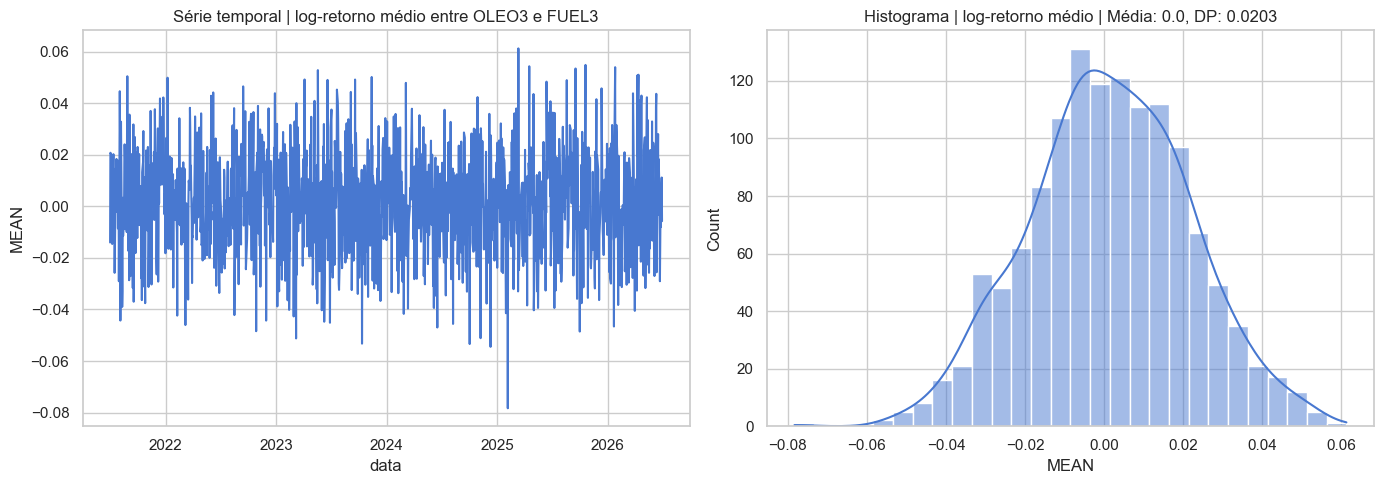

In [374]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.lineplot(data=log_returns['MEAN'], ax=axes[0])
axes[0].set_title('Série temporal | log-retorno médio entre OLEO3 e FUEL3')

sns.histplot(data=log_returns['MEAN'], ax=axes[1], kde=True)
axes[1].set_title(f'Histograma | log-retorno médio | Média: {log_returns['MEAN'].mean():.1f}, DP: {log_returns['MEAN'].std():.4f}')
plt.tight_layout()
plt.show()



## 2 - Modelagem para gerar as estimativas pontuais



### Selecionando dados de interesse

Afinal, queremos saber dos valores após a marcação `M10`, então vamos trabalhar com esses dados somente.

In [375]:

# Coletando a data e valor da marcação M10
date_m10 = markers[markers['marcacao'] == 'M10'].index[0]
value_m10 = markers.loc[date_m10, 'valor']


post_m10_log_returns = log_returns.loc[date_m10:]

# Garantir que a variação acumulada no dia do lançamento de M10 seja nula
post_m10_log_returns.loc[date_m10, 'MEAN'] = 0

### Obtendo o log-retorno acumulado

Partindo do pressuposto que os log-retornos são aditivos, podemos obter o retorno total acumulado desde o lançamento de `M10` para todos os dias até o lançamento de `M11`:

In [376]:

cumsum_log_return = post_m10_log_returns.cumsum()


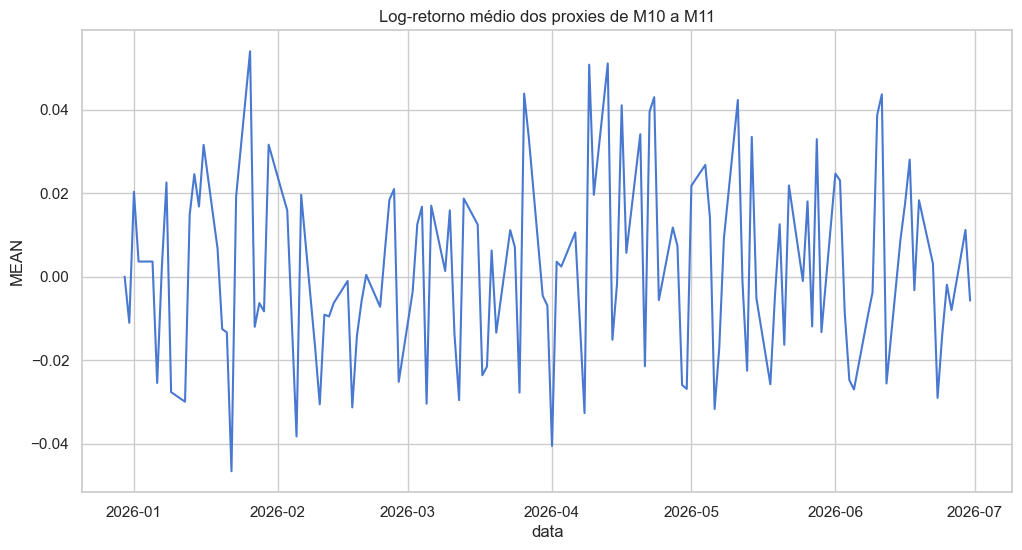

In [377]:
plt.figure(figsize=(12,6))
sns.lineplot(post_m10_log_returns['MEAN'])
plt.title('Log-retorno médio dos proxies de M10 a M11')
plt.show()

### Obtendo as previsões para os marcadores

A partir da fórmula abaixo, calculamos os valores previstos para o marcador nas datas intermediárias até o lançamento de `M11`:

$$
\hat{M_t} = M_{10} \cdot e^{(\sum_{i=T_{10}}^t r_{i})}
$$

Em que $\hat{M_t}$ é a estimativa de preço para toda data $t$ entre $T_{10}$ e $T_{11}$. Note que $r_i$ é o log-retorno médio dos proxies.

In [378]:

marker_estimates = value_m10 * np.exp(cumsum_log_return)
marker_estimates.columns = ['MARKER_ESTIMATE']


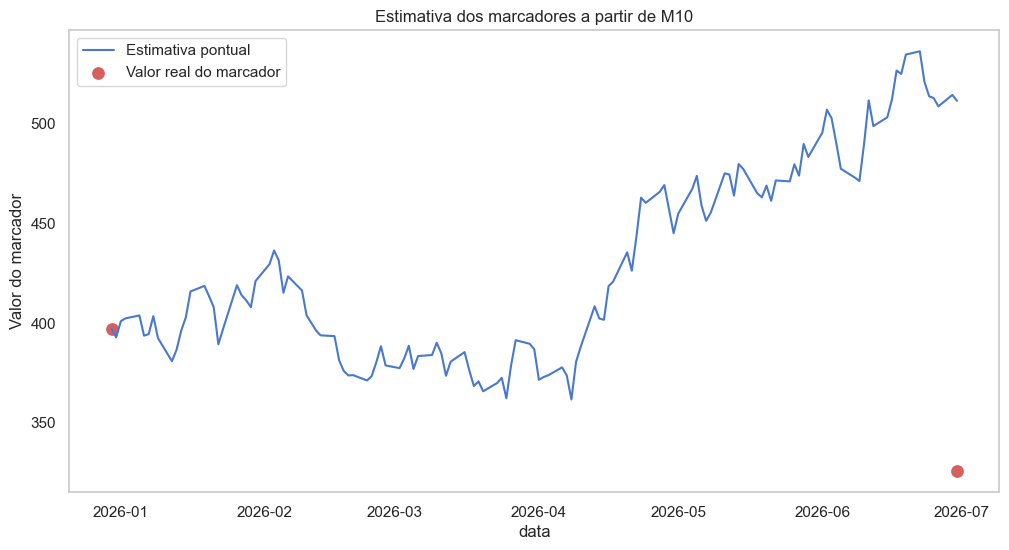

In [379]:

plt.figure(figsize=(12,6))
sns.lineplot(data=marker_estimates, x='data', y='MARKER_ESTIMATE', color='b', label='Estimativa pontual')
sns.scatterplot(data=markers.loc[date_m10:], x='data', y='valor', color='r', label='Valor real do marcador', s=100)
plt.ylabel('Valor do marcador')
plt.title('Estimativa dos marcadores a partir de M10')
plt.grid(False)
plt.show()

### Criando a função para estimação pontual

Agora, com as previsões feitas, basta definir uma função única que retorne uma estimativa pontual a partir de uma data inserida.

#### Recursos de robustez

O método recebe o dia, mês e ano - adaptando para o formato de data e captando erros de dados inválidos. Também verifica se a data está dentro do intervalo de interesse.

Note que, como os valores dos proxys são publicados apenas em dias úteis, utilizamos a função `asof` do Pandas que nos permite retornar o valor da data mais próxima da inserida (caso ela seja em um final de semana, por exemplo).

In [380]:

def return_marker_estimate(day:int, month:int, year:int)-> str:

    try:
        date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")

    except Exception as e:
        return "ERRO: Insira uma data válida"


    if date < marker_estimates.index.min() or date > marker_estimates.index.max():
        return f"ERRO: Insira uma data após o lançamento de M10 ({marker_estimates.index.min().strftime('%d/%m/%Y')}) até o dia do lançamento de M11 ({marker_estimates.index.max().strftime('%d/%m/%Y')})"

    closest_estimate = float(marker_estimates['MARKER_ESTIMATE'].asof(date))

    return f"Valor estimado para {date.strftime('%d/%m/%Y')} : R$ {closest_estimate:.2f}"


## Sinta-se à vontade para testar a função aqui!

In [382]:
day = 19
month = 4
year = 2026

return_marker_estimate(day, month, year)


'Valor estimado para 19/04/2026 : R$ 420.81'

# 3 - Análise de resultados

Ao calcularmos o estimador $\hat{M}_{11}$ obtivemos o resultado $511.39$, significativamente acima do valor real $M_{11} = 325.66$. Um erro dessa magnitude nos permite inferir que o valor do marcador da empresa não foi influenciado somente por fatores sistêmicos (como os indicadores de mercado), mas também por fatores indiosincráticos - atrelados unicamente à empresa em si, como problemas internos - o que é depois tratado na fase 1.

Em geral, parte da limitação se dá pela própria natureza dos dados: as marcações da empresa são uma fotografia semestral de um ativo sem liquidez, o que os torna mais difícil de projetar a partir de dados sistêmicos.

Em relação ao model, o uso do retorno médio entre `OLEO3` e `FUEL3` demonstrou a limitação da média simples (50/50) para a predição. Uma modelagem alternativa possível seria utilizar da regressão linear simples para se obter parâmetros mais aproximados para os retornos.
